In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
def load_mnist_images(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=16)
    return data.reshape(-1, 28*28)

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
    return data

In [3]:
base_path = '/kaggle/input/mnist-digital'

X_train = load_mnist_images(base_path + '/train-images.idx3-ubyte')
X_test  = load_mnist_images(base_path + '/t10k-images.idx3-ubyte')

y_train = load_mnist_labels(base_path + '/train-labels.idx1-ubyte')
y_test  = load_mnist_labels(base_path + '/t10k-labels.idx1-ubyte')

In [4]:
X_train = X_train / 255.0
X_test  = X_test / 255.0

In [5]:
model = LogisticRegression(max_iter=1000, n_jobs=-1)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, n_jobs=-1)

In [6]:
y_pred = model.predict(X_test)

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.926

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.89      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



In [8]:
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:

[[ 958    0    1    3    1    9    4    3    1    0]
 [   0 1111    4    2    0    2    3    2   11    0]
 [   6    9  930   16   10    3   12    9   33    4]
 [   4    1   17  922    1   25    2   10   19    9]
 [   1    3    7    3  920    0    7    4    6   31]
 [   9    2    3   35    9  779   15    6   30    4]
 [   8    3    8    2    7   16  911    2    1    0]
 [   1    7   24    6    6    1    0  949    1   33]
 [   9   11    6   21    8   29   14    9  855   12]
 [   9    8    1    9   21    6    0   22    8  925]]


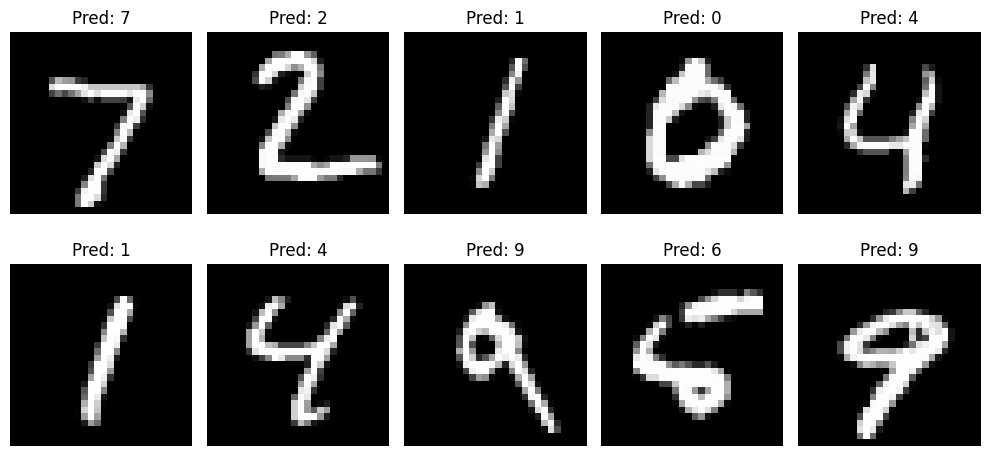

In [9]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()